# 文件: chart_9_1.py

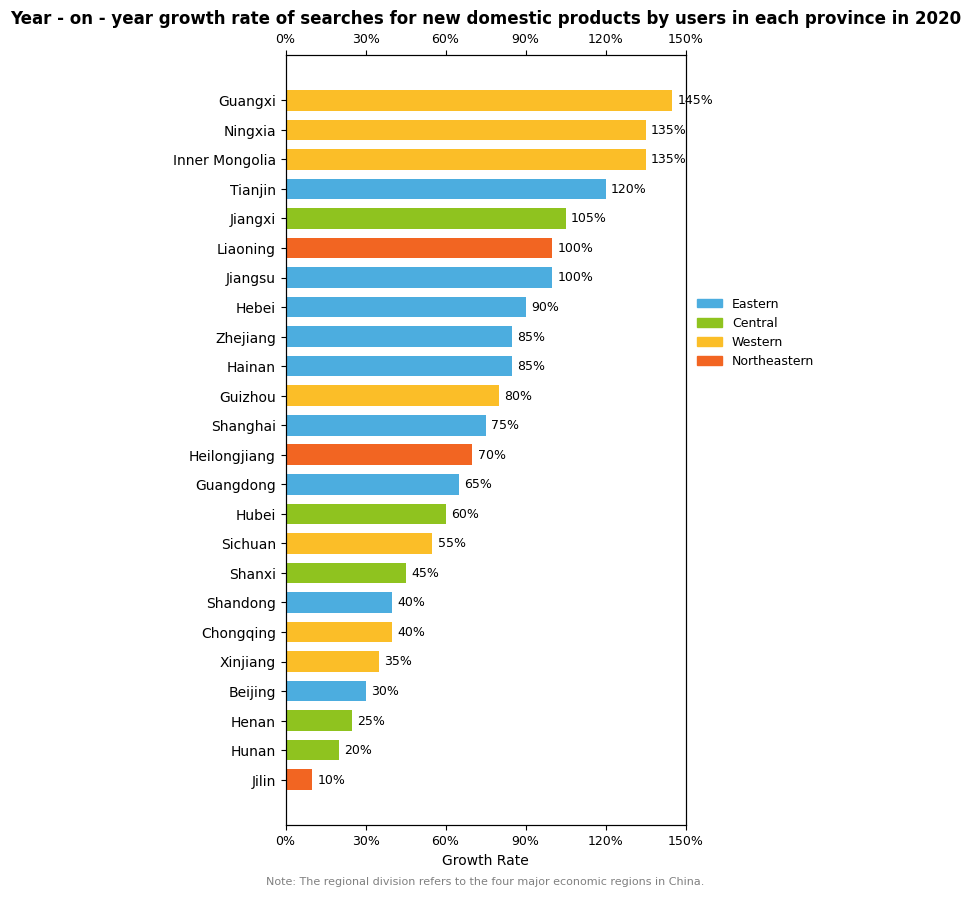

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Define data strictly according to the chart order (keep the original order)
data = [
    {"province": "Guangxi", "region": "Western", "growth": 145},
    {"province": "Ningxia", "region": "Western", "growth": 135},
    {"province": "Inner Mongolia", "region": "Western", "growth": 135},
    {"province": "Tianjin", "region": "Eastern", "growth": 120},
    {"province": "Jiangxi", "region": "Central", "growth": 105},
    {"province": "Liaoning", "region": "Northeastern", "growth": 100},
    {"province": "Jiangsu", "region": "Eastern", "growth": 100},
    {"province": "Hebei", "region": "Eastern", "growth": 90},
    {"province": "Zhejiang", "region": "Eastern", "growth": 85},
    {"province": "Hainan", "region": "Eastern", "growth": 85},
    {"province": "Guizhou", "region": "Western", "growth": 80},
    {"province": "Shanghai", "region": "Eastern", "growth": 75},
    {"province": "Heilongjiang", "region": "Northeastern", "growth": 70},
    {"province": "Guangdong", "region": "Eastern", "growth": 65},
    {"province": "Hubei", "region": "Central", "growth": 60},
    {"province": "Sichuan", "region": "Western", "growth": 55},
    {"province": "Shanxi", "region": "Central", "growth": 45},
    {"province": "Shandong", "region": "Eastern", "growth": 40},
    {"province": "Chongqing", "region": "Western", "growth": 40},
    {"province": "Xinjiang", "region": "Western", "growth": 35},
    {"province": "Beijing", "region": "Eastern", "growth": 30},
    {"province": "Henan", "region": "Central", "growth": 25},
    {"province": "Hunan", "region": "Central", "growth": 20},
    {"province": "Jilin", "region": "Northeastern", "growth": 10}
]

# Extract data
provinces = [item["province"] for item in data]
regions = [item["region"] for item in data]
growths = [item["growth"] for item in data]

# Region - color mapping (strictly match the original image)
region_color = {
    "Eastern": "#4CADDF",  # Blue
    "Central": "#8FC31F",  # Green
    "Western": "#FBBE28",  # Orange
    "Northeastern": "#F26522"  # Red
}
colors = [region_color[reg] for reg in regions]

# Create a canvas
plt.figure(figsize=(8, 10))  # Adjust the canvas size to fit the data

# Create the main x - axis (bottom x - axis)
ax1 = plt.subplot(111)

# Draw a horizontal bar chart (the order of Y - axis data is reversed)
y_pos = np.arange(len(provinces))
bars = ax1.barh(y_pos[::-1], growths, color=colors, height=0.7)

# Set Y - axis labels (province names, keep the original order)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(provinces[::-1], fontsize=10)

# Set the bottom x - axis ticks (percentage format)
ax1.set_xlim(0, 150)
ax1.set_xticks([0, 30, 60, 90, 120, 150])
ax1.set_xticklabels(["0%", "30%", "60%", "90%", "120%", "150%"], fontsize=9)
ax1.set_xlabel("Growth Rate", fontsize=10)

# Create the top x - axis (share the Y - axis with the bottom x - axis)
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())  # Ensure the top and bottom x - axes have the same range
ax2.set_xticks([0, 30, 60, 90, 120, 150])
ax2.set_xticklabels(["0%", "30%", "60%", "90%", "120%", "150%"], fontsize=9)

# Add a title
plt.title("Year - on - year growth rate of searches for new domestic products by users in each province in 2020",
          fontsize=12, fontweight="bold", y=1.03)

# Manually build the legend (match the original position and style)
from matplotlib.patches import Patch
legend_patches = [
    Patch(color=region_color["Eastern"], label="Eastern"),
    Patch(color=region_color["Central"], label="Central"),
    Patch(color=region_color["Western"], label="Western"),
    Patch(color=region_color["Northeastern"], label="Northeastern")
]
ax1.legend(handles=legend_patches, bbox_to_anchor=(1, 0.7),
           fontsize=9, frameon=False)

# Adjust the layout (avoid overlapping of legend and content)
plt.subplots_adjust(left=0.3, right=0.8)  # Reserve space on the right for the legend

# Add data labels (correct the order)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width + 2, bar.get_y() + bar.get_height() / 2,
             f"{growths[i]}%",  # Correct the index, directly use i
             ha='left', va='center', fontsize=9)

# Add a note (strictly restore the bottom note)
plt.figtext(0.55, 0.05, "Note: The regional division refers to the four major economic regions in China.",
            ha="center", fontsize=8, color="gray")

# Display the chart
plt.show()

# 文件: chart_9_2.py

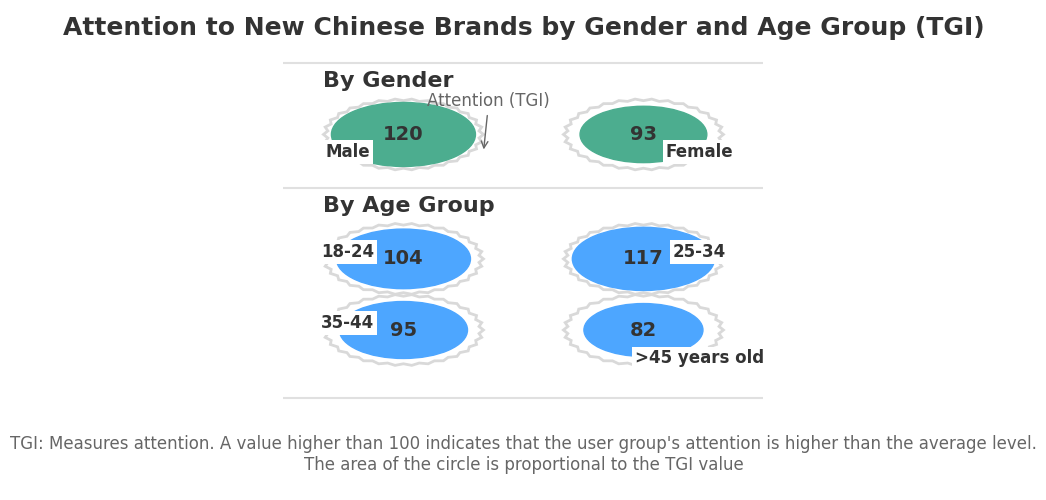

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, PathPatch
from matplotlib.path import Path

# Data configuration (combine gender and age groups)
data = {
    "gender": {
        "groups": ["Male", "Female"],
        "tgi": [120, 93],
        "outer_color": "#D9D9D9",  # Outer serrated ring color
        "inner_colors": ["#4CAD8F", "#4CAD8F"],  # Inner circle colors (dark for male, light for female)
        "title": "By Gender",
        "label_pos": [(-2.2, 0.5), (2.2, 0.5)],  # Label positions (distributed left and right)
        "annotation": "Attention (TGI)"  # Annotation text
    },
    "age": {
        "groups": ["18-24", "25-34", "35-44", ">45 years old"],
        "tgi": [104, 117, 95, 82],
        "outer_color": "#D9D9D9",  # Outer serrated ring color
        "inner_colors": ["#4DA6FF", "#4DA6FF", "#4DA6FF", "#4DA6FF"],  # Blue
        "title": "By Age Group",
        "label_pos": [(-2.2, 1.2), (2.2, 1.2), (-2.2, -0.8), (2.2, -1.8)],  # Label positions
        "annotation": ""  # Do not repeat annotation for age groups
    }
}

# Create a canvas (adjust the height to accommodate two groups)
fig = plt.figure(figsize=(6, 8), facecolor='white')  # Increase the canvas height
ax = fig.add_subplot(111)

# Core function to draw a serrated outer frame
def draw_serrated_ring(center, radius, color, num_teeth=30):
    """
    Draw a fixed outer frame with serrations
    :param center: Coordinates of the circle center (x, y)
    :param radius: Radius of the outer frame
    :param color: Color of the outer frame
    :param num_teeth: Number of serrations (controls aesthetics)
    """
    theta = np.linspace(0, 2 * np.pi, num_teeth * 2, endpoint=False)
    radii = np.array([radius, radius * 0.95] * num_teeth)
    path_data = []
    for t, r in zip(theta, radii):
        x = center[0] + r * np.cos(t)
        y = center[1] + r * np.sin(t)
        path_data.append((Path.MOVETO if t == 0 else Path.LINETO, (x, y)))
    
    # Close the path
    path_data.append((Path.CLOSEPOLY, (center[0], center[1])))
    codes, verts = zip(*path_data)
    path = Path(verts, codes)
    patch = PathPatch(path, facecolor='none', edgecolor=color, lw=2)
    ax.add_patch(patch)

# Function to draw a dynamic inner circle
def draw_dynamic_inner_circle(center, tgi, color, max_tgi=120):
    """
    Draw an inner circle that changes dynamically with TGI
    :param center: Coordinates of the circle center (x, y)
    :param tgi: TGI value
    :param color: Color of the inner circle
    :param max_tgi: Maximum TGI (used for normalization)
    """
    # Calculate the radius of the inner circle according to the TGI ratio
    radius_ratio = np.sqrt(tgi / max_tgi)
    base_radius = 0.9  # Base radius (relative to the outer frame radius of 1.0)
    radius = base_radius * radius_ratio
    
    inner_circle = Circle(center, radius, color=color, zorder=2)
    ax.add_artist(inner_circle)
    
    # Add TGI text
    ax.text(
        center[0], center[1], 
        f"{tgi}", 
        ha='center', 
        va='center', 
        fontsize=14, 
        fontweight='bold', 
        color='#333333',
        zorder=3
    )

# Function to draw a separator line
def draw_separator(y_pos, length=6, color='#E0E0E0', linestyle='-', linewidth=1.5):
    """
    Draw a horizontal separator line
    :param y_pos: Y-coordinate position of the separator line
    :param length: Length of the separator line
    :param color: Color of the separator line
    :param linestyle: Line style
    :param linewidth: Line width
    """
    x_start = -length / 2
    x_end = length / 2
    ax.plot([x_start, x_end], [y_pos, y_pos], color=color, linestyle=linestyle, linewidth=linewidth, zorder=1)

# Draw all groups
for group_type, group_data in data.items():
    # Vertical offset (gender group on top, age group on bottom)
    y_offset = -3.5 if group_type == "age" else 0  # Adjust the vertical offset
    
    # Draw all circles for each group
    for i, (group, tgi, color) in enumerate(zip(
        group_data["groups"], 
        group_data["tgi"], 
        group_data["inner_colors"]
    )):
        # Calculate the center position (alternate left and right)
        center = (1.5 if i % 2 == 1 else -1.5, y_offset + (1.0 if i < 2 else -1.0))
        
        # Draw the serrated outer frame
        draw_serrated_ring(center, radius=1.0, color=group_data["outer_color"])
        
        # Draw the dynamic inner circle
        draw_dynamic_inner_circle(center, tgi, color)
        
        # Add group labels
        label_x, label_y = group_data["label_pos"][i]
        ax.text(
            label_x, label_y + y_offset, 
            group, 
            ha='center', 
            va='center', 
            fontsize=12, 
            fontweight='bold', 
            color='#333333',
            bbox=dict(facecolor='white', edgecolor='none', pad=2),
            zorder=4
        )
    
    # Move the group title up
    title_y = 2.5 + y_offset
    ax.text(
        -2.5, title_y, 
        group_data["title"], 
        ha='left', 
        va='center', 
        fontsize=16, 
        fontweight='bold', 
        color='#333333',
        zorder=5
    )
    
    # Move the annotation arrow up
    if group_data["annotation"]:
        ax.annotate(
            group_data["annotation"], 
            xy=(-0.5, 0.5 + y_offset), 
            xytext=(-1.2, 1.8 + y_offset),
            arrowprops=dict(arrowstyle='->', color='#666666'),
            fontsize=12, 
            color='#666666',
            zorder=6
        )

# Add the overall title
ax.text(
    0, 4.0,  # Move the overall title up
    "Attention to New Chinese Brands by Gender and Age Group (TGI)", 
    ha='center', 
    va='center', 
    fontsize=18, 
    fontweight='bold', 
    color='#333333',
    zorder=7
)

# Move the bottom description text down
ax.text(
    0, -8.0,  # Move the bottom text further down
    "TGI: Measures attention. A value higher than 100 indicates that the user group's attention is higher than the average level.\n"
    "The area of the circle is proportional to the TGI value", 
    ha='center', 
    va='center', 
    fontsize=12, 
    color='#666666',
    zorder=8
)

# Draw three separator lines
draw_separator(y_pos=3.0)  # Separate the title and the gender group
draw_separator(y_pos=-0.5)  # Separate the gender group and the age group
draw_separator(y_pos=-6.4)  # Separate the age group and the bottom annotation

# Set the axis range
ax.set_xlim(-3, 3)
ax.set_ylim(-9, 4.5)  # Expand the Y-axis range to accommodate all content
ax.axis('off')  # Hide the axes

# Adjust the layout
plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.25)
plt.show()

# 文件: chart_9_3.py

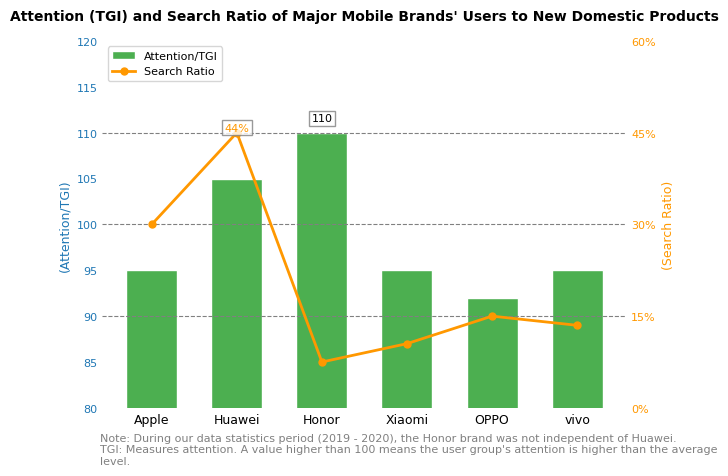

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Data definition
brands = ['Apple', 'Huawei', 'Honor', 'Xiaomi', 'OPPO', 'vivo']
tgi_data = [95, 105, 110, 95, 92, 95]  # Attention (TGI) data
search_ratio_raw = [100, 110, 85, 87, 90, 89]  # Raw values of search ratio line chart
search_percent_labels = [30, 44, 5, 7, 10, 8]  # Actual search percentages to be labeled
highlight_huawei = (1, 44)  # Special label for Huawei (index, label value)
highlight_honor = (2, 110)  # Special label for Honor (index, label value)

# Initialize the chart and dual - axis
fig, ax1 = plt.subplots(figsize=(7, 5), dpi=100)
ax2 = ax1.twinx()

# Draw the bar chart (TGI)
x = np.arange(len(brands))  # Specify tick positions clearly
bar_plot = ax1.bar(x, tgi_data, color='#4CAF50', width=0.6, edgecolor='white')
ax1.set_ylim(80, 120)
ax1.set_ylabel('(Attention/TGI)', color='#1f77b4', fontsize=9)
ax1.tick_params(axis='y', labelcolor='#1f77b4', labelsize=8, length=0)  # Remove y - axis tick lines
ax1.set_xticks(x)  # New: Explicitly set tick positions
ax1.set_xticklabels(brands, fontsize=9)
ax1.tick_params(axis='x', length=0)  # Remove x - axis tick lines

# Draw the line chart (Search ratio)
line_plot, = ax2.plot(x, search_ratio_raw, color='#FF9800', marker='o', markersize=5, linewidth=2)
ax2.set_ylim(80, 120)
ax2.set_ylabel('(Search Ratio)', color='#FF9800', fontsize=9)
ax2.tick_params(axis='y', labelcolor='#FF9800', labelsize=8, length=0)  # Remove y - axis tick lines

# Map the right - hand axis to percentages
def map_to_percent(tick):
    return ((tick - 80) / (120 - 80)) * 60

# Customize the right - hand axis ticks and labels
ax2.set_yticks([80, 90, 100, 110, 120])
ax2.set_yticklabels([f'{map_to_percent(tick):.0f}%' for tick in [80, 90, 100, 110, 120]], fontsize=8)

# Add dashed auxiliary lines (refer to the original chart)
for y in [90, 100, 110]:
    ax1.axhline(y, color='gray', linestyle='--', linewidth=0.8)

# Special data labels (Huawei 44%, Honor 110)
# Label for Huawei's line chart point
ax2.text(highlight_huawei[0], search_ratio_raw[highlight_huawei[0]], 
         f'{highlight_huawei[1]}%', 
         ha='center', va='bottom', fontsize=8, color='#FF9800',
         bbox=dict(facecolor='white', edgecolor='gray', pad=2, alpha=0.8))
# Label for Honor's bar chart
ax1.text(highlight_honor[0], tgi_data[highlight_honor[0]] + 1, 
         f'{highlight_honor[1]}', 
         ha='center', va='bottom', fontsize=8, color='black',
         bbox=dict(facecolor='white', edgecolor='gray', pad=2, alpha=0.8))

# Title and annotation
plt.title('Attention (TGI) and Search Ratio of Major Mobile Brands\' Users to New Domestic Products', fontsize=10, fontweight='bold', pad=15)

annotation_text = (
    'Note: During our data statistics period (2019 - 2020), the Honor brand was not independent of Huawei.\n'
    'TGI: Measures attention. A value higher than 100 means the user group\'s attention is higher than the average level.'
)
plt.figtext(0.12, 0.01, annotation_text, fontsize=8, color='gray', wrap=True)

# Legend and layout optimization
ax1.legend([bar_plot, line_plot], ['Attention/TGI', 'Search Ratio'], 
           loc='upper left', fontsize=8, frameon=True, facecolor='white')
plt.tight_layout(pad=3)

# Remove the chart border
for spine in ax1.spines.values():
    spine.set_visible(False)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.show()

# 文件: chart_9_4.py

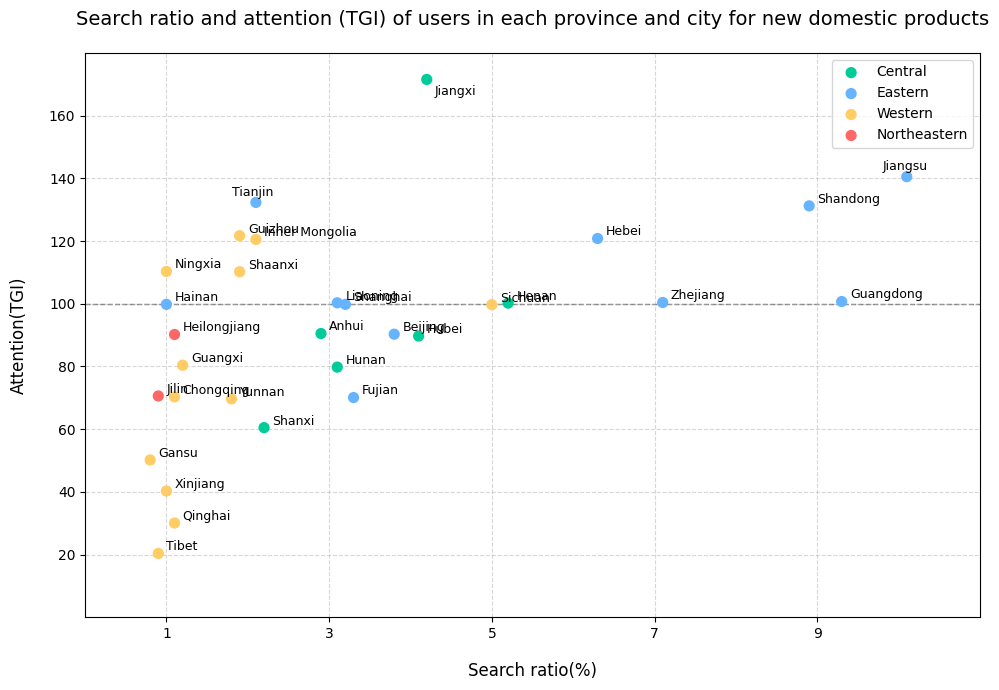

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import random

# Set the random seed to ensure reproducibility of results
np.random.seed(42)
random.seed(42)

# Accurately extract chart data, adjust it to floating - point numbers and add a slight random offset
# Data format: Province: (Search ratio, Attention TGI, Region, Color)
province_data = {
    "Jiangxi": (4.2, 171.5, "Central", "#00cc99"),
    "Tianjin": (2.1, 132.3, "Eastern", "#66b3ff"),
    "Guizhou": (1.9, 121.7, "Western", "#ffcc66"),
    "Hebei": (6.3, 120.8, "Eastern", "#66b3ff"),
    "Shandong": (8.9, 131.2, "Eastern", "#66b3ff"),
    "Jiangsu": (10.1, 140.5, "Eastern", "#66b3ff"),
    "Ningxia": (1.0, 110.3, "Western", "#ffcc66"),
    "Shanghai": (3.2, 99.8, "Eastern", "#66b3ff"),
    "Zhejiang": (7.1, 100.4, "Eastern", "#66b3ff"),
    "Guangdong": (9.3, 100.7, "Eastern", "#66b3ff"),
    "Heilongjiang": (1.1, 90.2, "Northeastern", "#ff6666"),
    "Anhui": (2.9, 90.5, "Central", "#00cc99"),
    "Hubei": (4.1, 89.7, "Central", "#00cc99"),
    "Beijing": (3.8, 90.3, "Eastern", "#66b3ff"),
    "Guangxi": (1.2, 80.4, "Western", "#ffcc66"),
    "Hunan": (3.1, 79.8, "Central", "#00cc99"),
    "Jilin": (0.9, 70.6, "Northeastern", "#ff6666"),
    "Fujian": (3.3, 70.1, "Eastern", "#66b3ff"),
    "Chongqing": (1.1, 70.3, "Western", "#ffcc66"),
    "Yunnan": (1.8, 69.7, "Western", "#ffcc66"),
    "Shanxi": (2.2, 60.5, "Central", "#00cc99"),
    "Gansu": (0.8, 50.2, "Western", "#ffcc66"),
    "Xinjiang": (1.0, 40.3, "Western", "#ffcc66"),
    "Qinghai": (1.1, 30.1, "Western", "#ffcc66"),
    "Tibet": (0.9, 20.4, "Western", "#ffcc66"),
    "Henan": (5.2, 100.2, "Central", "#00cc99"),
    "Hainan": (1.0, 99.8, "Eastern", "#66b3ff"),
    "Liaoning": (3.1, 100.3, "Eastern", "#66b3ff"),
    "Sichuan": (5.0, 99.7, "Western", "#ffcc66"),
    "Inner Mongolia": (2.1, 120.5, "Western", "#ffcc66"),
    "Shaanxi": (1.9, 110.2, "Western", "#ffcc66"),
}

# Group by region
region_dict = defaultdict(list)
for prov, (ratio, tgi, region, color) in province_data.items():
    region_dict[region].append((prov, ratio, tgi, color))

# Create a canvas
plt.figure(figsize=(10, 7), facecolor='white')
ax = plt.gca()

# Draw a scatter plot (loop by region)
for region, prov_list in region_dict.items():
    ratios = [d[1] for d in prov_list]
    tgis = [d[2] for d in prov_list]
    colors = [d[3] for d in prov_list]
    ax.scatter(ratios, tgis, c=colors, label=region, s=50, zorder=2)

    # Add province text labels (fine - tune the position to avoid overlap)
    for d in prov_list:
        prov, ratio, tgi, _ = d
        # Manually fine - tune the label positions of some provinces (adjust according to the original image vision)
        if prov == 'Jiangxi':
            ax.text(ratio + 0.1, tgi - 5, prov, fontsize=9)
        elif prov in ['Tianjin', 'Jiangsu']:
            ax.text(ratio - 0.3, tgi + 2, prov, fontsize=9)
        else:
            ax.text(ratio + 0.1, tgi + 1, prov, fontsize=9)

# Draw a reference line for Attention TGI = 100
ax.axhline(y=100, color='gray', linestyle='--', linewidth=1, zorder=1)

# Set axis labels
ax.set_xlabel('Search ratio(%)', fontsize=12, labelpad=15)
ax.set_ylabel('Attention(TGI)', fontsize=12, labelpad=15)

# Set the title
ax.set_title('Search ratio and attention (TGI) of users in each province and city for new domestic products', fontsize=14, pad=20)

# Adjust the axis range and ticks
ax.set_xlim(0, 11)
ax.set_ylim(0, 180)
ax.set_xticks([1, 3, 5, 7, 9])  # Strictly match the x - axis ticks of the original image
ax.set_yticks(range(20, 180, 20))

# Set the legend (align the position with the original image)
ax.legend(loc='upper right', bbox_to_anchor=(1, 1), frameon=True, fontsize=10)

# Add a grid
ax.grid(linestyle='--', alpha=0.5, zorder=0)

# Optimize the layout
plt.tight_layout()
plt.show()